## Этап 1. Подготовка данных
- Изучение датасета
- Оценка полноты, чистоты и структуры
- Приведение данных к удобному виду 

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_sessions_orig = pd.read_csv('data/ga_sessions.csv', low_memory=False)
df_hits_orig = pd.read_csv('data/ga_hits.csv', low_memory=False)

In [38]:
df_sessions = df_sessions_orig.copy()
df_hits = df_hits_orig.copy()

print('df_sessions')
display(df_sessions.head())
print(df_sessions.info())

print('df_sessions')
display(df_hits.head())
print(df_hits.info())

df_sessions


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


<class 'pandas.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype
---  ------                    -----
 0   session_id                str  
 1   client_id                 str  
 2   visit_date                str  
 3   visit_time                str  
 4   visit_number              int64
 5   utm_source                str  
 6   utm_medium                str  
 7   utm_campaign              str  
 8   utm_adcontent             str  
 9   utm_keyword               str  
 10  device_category           str  
 11  device_os                 str  
 12  device_brand              str  
 13  device_model              str  
 14  device_screen_resolution  str  
 15  device_browser            str  
 16  geo_country               str  
 17  geo_city                  str  
dtypes: int64(1), str(17)
memory usage: 593.3 MB
None
df_sessions


,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   session_id      str    
 1   hit_date        str    
 2   hit_time        float64
 3   hit_number      int64  
 4   hit_type        str    
 5   hit_referer     str    
 6   hit_page_path   str    
 7   event_category  str    
 8   event_action    str    
 9   event_label     str    
 10  event_value     float64
dtypes: float64(2), int64(1), str(8)
memory usage: 5.0 GB
None


In [39]:
print('Пропуски в df_sessions в %')
print((df_sessions.isna().sum() / len(df_sessions) * 100).round(2).sort_values(ascending=False))
print(f'Дубликаты: {df_sessions.duplicated().sum()}\n')

print('Пропуски в df_hits')
print((df_hits.isna().sum() / len(df_hits) * 100).round(2).sort_values(ascending=False))
print(f'Дубликаты: {df_hits.duplicated().sum()}')

Пропуски в df_sessions в %
device_model                99.12
utm_keyword                 58.17
device_os                   57.53
device_brand                19.74
utm_adcontent               18.04
utm_campaign                11.81
utm_source                   0.01
session_id                   0.00
client_id                    0.00
visit_number                 0.00
utm_medium                   0.00
visit_date                   0.00
visit_time                   0.00
device_category              0.00
device_screen_resolution     0.00
device_browser               0.00
geo_country                  0.00
geo_city                     0.00
dtype: float64
Дубликаты: 0

Пропуски в df_hits
event_value       100.00
hit_time           58.25
hit_referer        39.90
event_label        23.91
session_id          0.00
hit_date            0.00
hit_number          0.00
hit_page_path       0.00
hit_type            0.00
event_action        0.00
event_category      0.00
dtype: float64
Дубликаты: 0


In [40]:
# Список всех уникальных действий 
with pd.option_context('display.max_rows', None):
    print(df_hits['event_action'].value_counts())

event_action
view_card                                   3558985
view_new_card                               3551009
sub_landing                                 1798117
go_to_car_card                               973666
sub_view_cars_click                          791515
search_form_region                           512069
search_form_search_btn                       433748
sap_search_form_cost_to                      356596
showed_number_ads                            326274
pagination_click                             248944
search_form_mark_select                      222652
quiz_show                                    214037
search_form_model_select                     211890
sap_search_form_cost_from                    188129
photos_all                                   181493
search_form_search_car_type_select           174877
photos                                       158543
sub_car_page                                 130310
view_more_click                              109971

In [41]:
# Выделение целевых признаков
target_actions = [
    # Заявки
    'sub_submit_success',
    'sub_car_claim_submit_click',
    'sub_car_request_submit_click',
    'sub_custom_question_submit_click',
    'greenday_sub_submit_success',
    
    # Звонки
    'sub_callback_submit_click',
    'greenday_sub_callback_submit_click',
    'callback_requested',
    
    # Чат
    'sub_open_dialog_click',
    'greenday_sub_open_dialog_click',
    'start_chat',
    'user_message',
    'user gave contacts during chat',
    'proactive invitation accepted'
]

# Создание нового датасета с зависисмостью: уникальная сессия - таргет
df_hits['is_target'] = df_hits['event_action'].isin(target_actions).astype(int) 
sessions_with_target = df_hits.groupby('session_id')['is_target'].max().reset_index()
df = pd.merge(sessions_with_target, df_sessions, on='session_id', how='left')

print('Пропуски в df')
print((df.isna().sum() / len(df) * 100).round(2).sort_values(ascending=False))


Пропуски в df
device_model                99.13
utm_keyword                 58.98
device_os                   58.59
device_brand                20.15
utm_adcontent               17.67
utm_campaign                11.39
client_id                    0.14
utm_medium                   0.14
visit_time                   0.14
utm_source                   0.14
visit_date                   0.14
device_screen_resolution     0.14
device_browser               0.14
visit_number                 0.14
device_category              0.14
geo_country                  0.14
geo_city                     0.14
is_target                    0.00
session_id                   0.00
dtype: float64


In [63]:
# Удаление 0.14% записей
df = df.dropna(subset='utm_source')

# Удаление device_model
df = df.drop(axis = 0, columns = 'device_model',)

# Заполнение пропусков
for col in ['utm_keyword', 'device_os', 'device_brand', 'utm_adcontent', 'utm_campaign']:
    if col in df.columns:
        df[col] = df[col].fillna('other')

print(f'Осталось пропусков:{df.isna().sum().max()}')


Осталось пропусков:0


In [64]:
# Выделение типов трафика 
df['is_organic'] = df['utm_medium'].isin(['organic', 'referral', '(none)']).astype(int)
# Платный трафик нет смысла добавлять колонку - is_organic = 0 - платный
# is_organic = 1 - органический

social_traffic_types = [
    'smm',
    'social', 
    'fb_smm',
    'vk_smm',
    'ok_smm',
    'blogger_channel',
    'blogger_stories',
    'blogger_header',
    'stories',
    'tg',
    'post'
]
df['is_social'] = df['utm_medium'].isin(social_traffic_types).astype(int)

## Этап 2. Разведочный анализ (EDA)


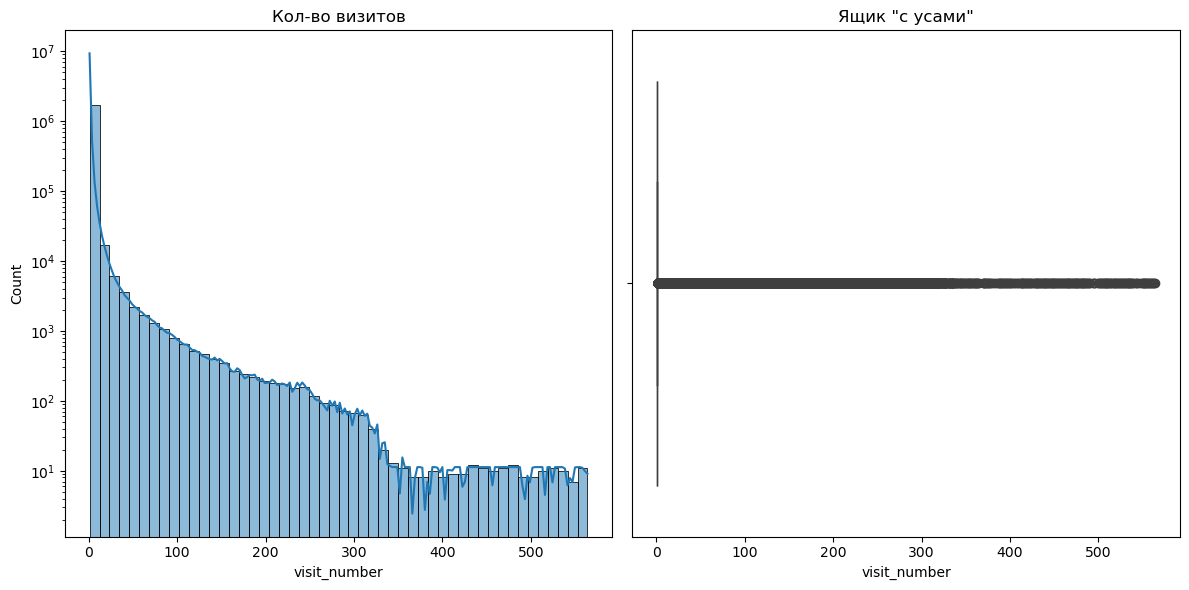

In [65]:
# распределение числовых признаков (кол-во визитов)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(df['visit_number'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Кол-во визитов')
axes[0].set_yscale('log')

sns.boxplot(x=df['visit_number'], ax=axes[1])
axes[1].set_title('Ящик "с усами"')

plt.tight_layout()
plt.show()

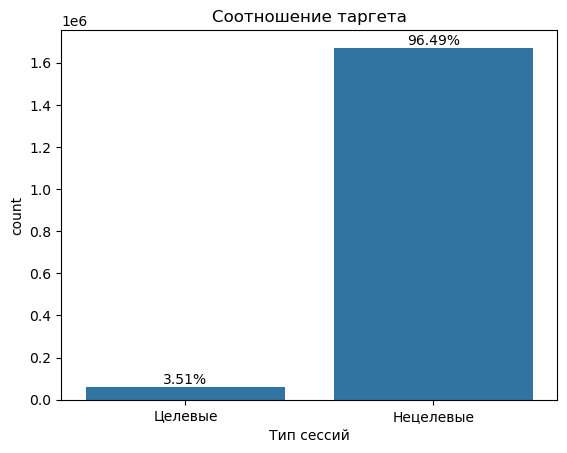

In [66]:
#  Соотношение таргета
ax = sns.countplot(data=df, x='is_target', order=[1, 0])
ax.set_title('Соотношение таргета')
ax.set_xlabel('Тип сессий')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Целевые', 'Нецелевые'])
total = len(df)

for p in ax.patches:
    ax.annotate(f'{100 * p.get_height() / total:.2f}%', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.show()

In [67]:
# Дополнительная статистика
v = df['visit_number']
print(f"Визиты: \nМакс: {v.max()}\nСред: {v.mean():.2f}\n95%: {v.quantile(0.95)}\n99%: {v.quantile(0.99)}\n")

t = df['is_target'].value_counts()
p = df['is_target'].value_counts(normalize=True)*100
print(f"Таргет:\n0: {t[0]} ({p[0]:.2f}%)\n1: {t[1]} ({p[1]:.2f}%)\nСоотношение 1:{int(t[0]/t[1])}\n")

c = df.groupby('is_organic')['is_target'].mean()*100
print(f"Трафик:\nОрганический: {c[1]:.2f}%\nПлатный: {c[0]:.2f}%")

Визиты: 
Макс: 564.0
Сред: 2.63
95%: 6.0
99%: 30.0

Таргет:
0: 1671398 (96.49%)
1: 60792 (3.51%)
Соотношение 1:27

Трафик:
Органический: 4.59%
Платный: 3.11%


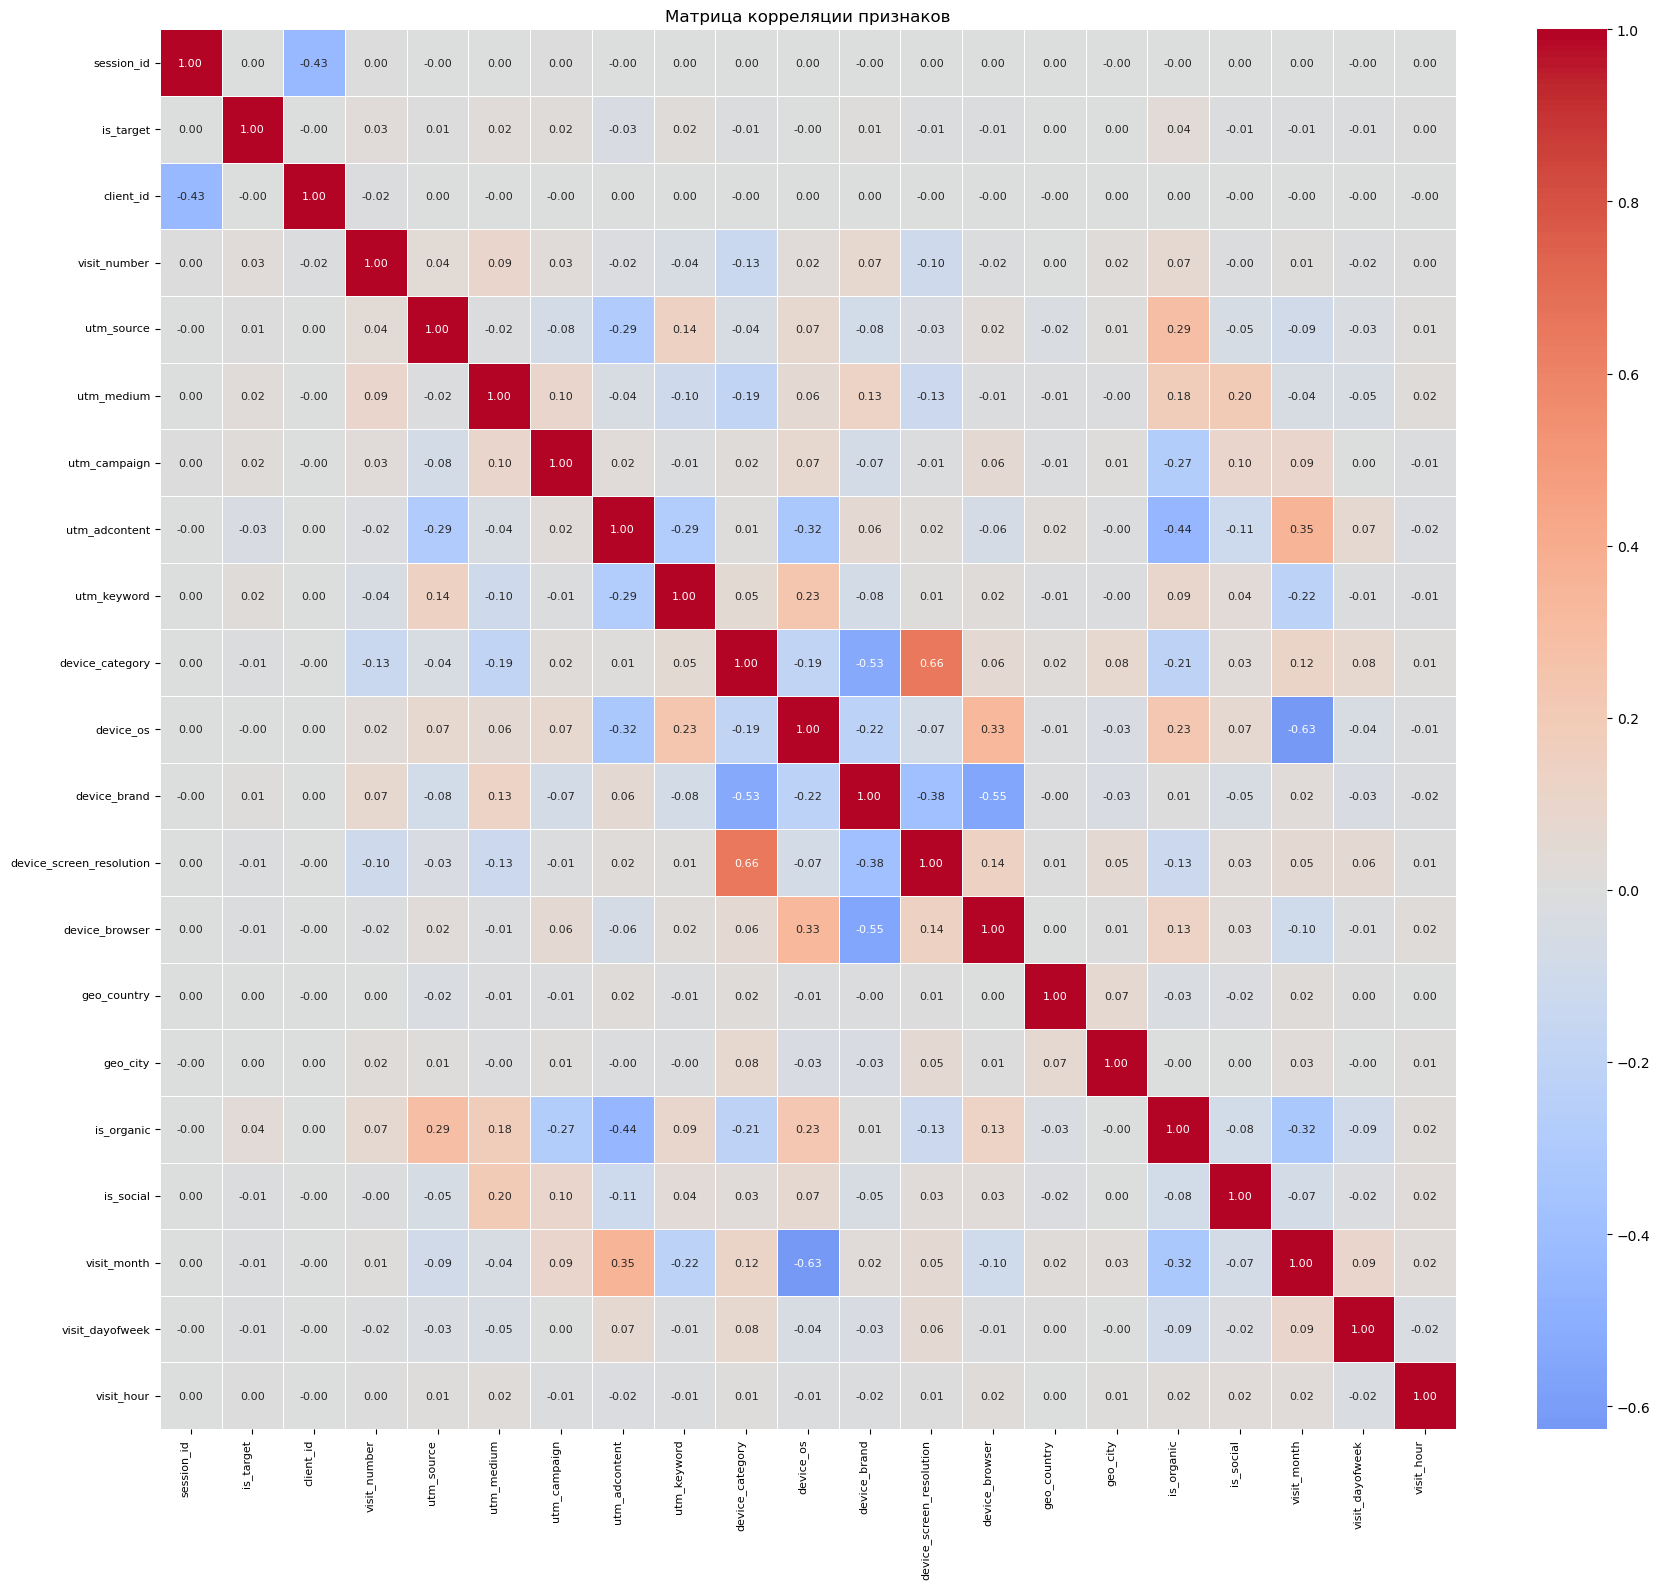

In [68]:
from sklearn.preprocessing import LabelEncoder

# Работа с датами
df['visit_date'] = pd.to_datetime(df['visit_date'])
df['visit_month'] = df['visit_date'].dt.month
df['visit_dayofweek'] = df['visit_date'].dt.dayofweek

df['visit_hour'] = pd.to_datetime(df['visit_time'], format='%H:%M:%S', errors='coerce').dt.hour

# Удаляем исходные колонки
df = df.drop(columns=['visit_date', 'visit_time'], errors='ignore').copy()

df_corr = df.copy()

# Кодирование строковых колонок для проверки корреляции
string_cols = df_corr.select_dtypes(include=['object', 'str']).columns

for col in string_cols:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

# Матрица корреляции
plt.figure(figsize=(18, 16))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", center=0, fmt='.2f',
            annot_kws={'size': 8}, linewidths=0.5)
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.title('Матрица корреляции признаков', fontsize=12)
plt.tight_layout()
plt.show()

### Вывод по этапу 2

Анализ целевой переменной зафиксировал сильный дисбаланс классов: конверсия составляет лишь 3.51% сессий при соотношении с нецелевыми 1:27. Исследование поведения пользователей показало, что количество визитов варьируется от 1 до 564 при среднем 2.63: 95% сессий укладываются в 6 визитов, а 99-й перцентиль достигает 30, что указывает на наличие аномально активных пользователей в правом хвосте распределения. Сравнение эффективности каналов выявило, что органический трафик конвертируется лучше платного (4.59% против 3.11%), что противоречит ожиданию о более высокой эффективности платных кампаний.

## Этап 3. Разработка прогностической модели (Machine Learning)

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

# режем выбросы в visit_number
df['visit_number'] = df['visit_number'].clip(upper=30)

# оставляем только популярные категории
def get_top_cats(df, col, n=20):
    top_list = df[col].value_counts().nlargest(n).index
    return df[col].apply(lambda x: x if x in top_list else -1)
                         
df['city_top'] = get_top_cats(df, 'geo_city')
df['source_top'] = get_top_cats(df, 'utm_source')

X = df.drop(['is_target', 'device_screen_resolution', 'session_id', 'client_id', 'geo_city', 'utm_source'], axis=1)
y = df['is_target']

for col in X.select_dtypes(include=['object', 'str']).columns:
    X[col] = X[col].astype(str)

categorical_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
    ('num', 'passthrough', numerical_cols)
])

# сплитим датасет
# stratify=y чтобы сохранить дисбаланс классов в обоих сетах
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающий набор (Train): {X_train.shape[0]} объектов \nКонверсия: {y_train.mean():.4f}\n")
print(f"Тестовый набор (Test):   {X_test.shape[0]} объектов \nКонверсия: {y_test.mean():.4f}")


Обучающий набор (Train): 1385752 объектов 
Конверсия: 0.0351

Тестовый набор (Test):   346438 объектов 
Конверсия: 0.0351



ROC-AUC: 0.6748


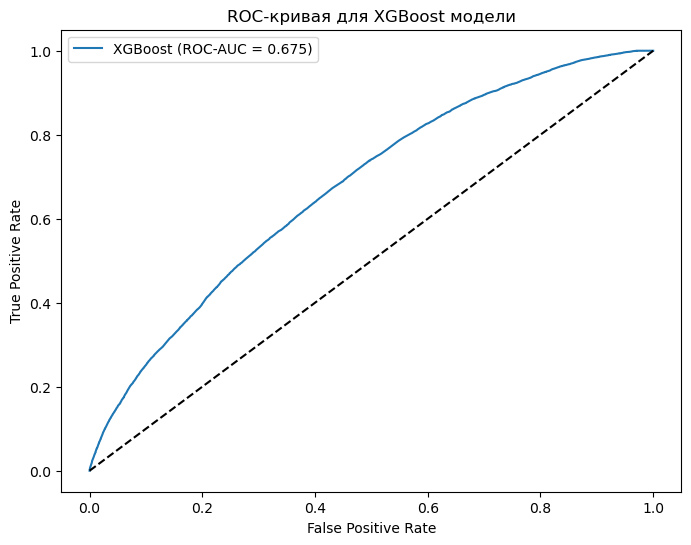

In [75]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

# XGBoost модель
model_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=27,
        max_depth=4,
        learning_rate=0.1,
        n_estimators=100,
        random_state=42,
        eval_metric='auc'
    ))
])

# Обучение модели
model_xgb.fit(X_train, y_train)

# метрики
y_pred_proba = model_xgb.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba)

print(f"\nROC-AUC: {roc_auc_xgb:.4f}")

# Визуализация ROC-кривой
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (ROC-AUC = {roc_auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая для XGBoost модели')
plt.legend()
plt.show()

In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Random Forest
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

model_rf.fit(X_train, y_train)

# скор
y_pred_rf = model_rf.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_pred_rf)

print(f"\nRandom Forest ROC-AUC: {roc_auc_rf:.4f}")
print(f"Абсолютный прирост метрики относительно XGB: +{roc_auc_rf - roc_auc_xgb:.4f}")



Random Forest ROC-AUC: 0.6778
Абсолютный прирост метрики относительно XGB: +0.0030


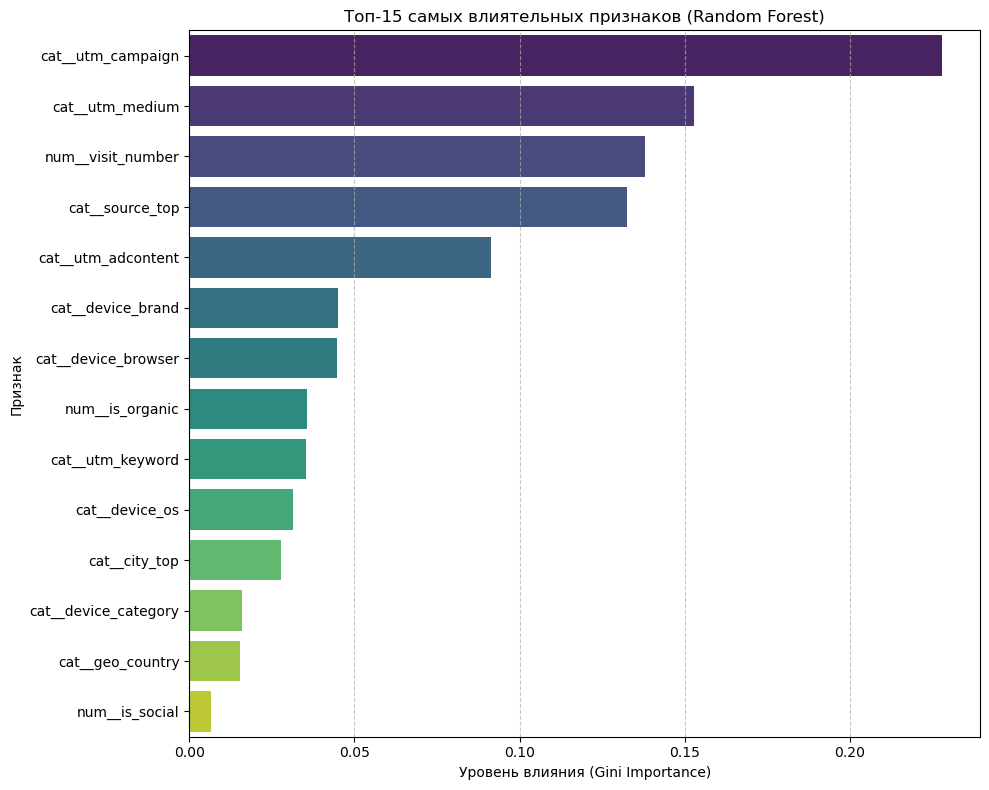


Random Forest Feature Importance Top-10:
            feature  importance
  cat__utm_campaign    0.227980
    cat__utm_medium    0.152711
  num__visit_number    0.137908
    cat__source_top    0.132436
 cat__utm_adcontent    0.091192
  cat__device_brand    0.045145
cat__device_browser    0.044670
    num__is_organic    0.035543
   cat__utm_keyword    0.035333
     cat__device_os    0.031384


In [77]:
# Feature importance Random Forest

feature_names = model_rf.named_steps['preprocessor'].get_feature_names_out()
importances_rf = model_rf.named_steps['classifier'].feature_importances_

rf_feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances_rf
}).sort_values(by='importance', ascending=False)

# Топ-15 фичей леса
plt.figure(figsize=(10, 8))
sns.barplot(data=rf_feature_importance.head(15), x='importance', y='feature', 
            hue='feature', palette='viridis', legend=False)
plt.title('Топ-15 самых влиятельных признаков (Random Forest)')
plt.xlabel('Уровень влияния (Gini Importance)')
plt.ylabel('Признак')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nRandom Forest Feature Importance Top-10:")
print(rf_feature_importance.head(10).to_string(index=False))

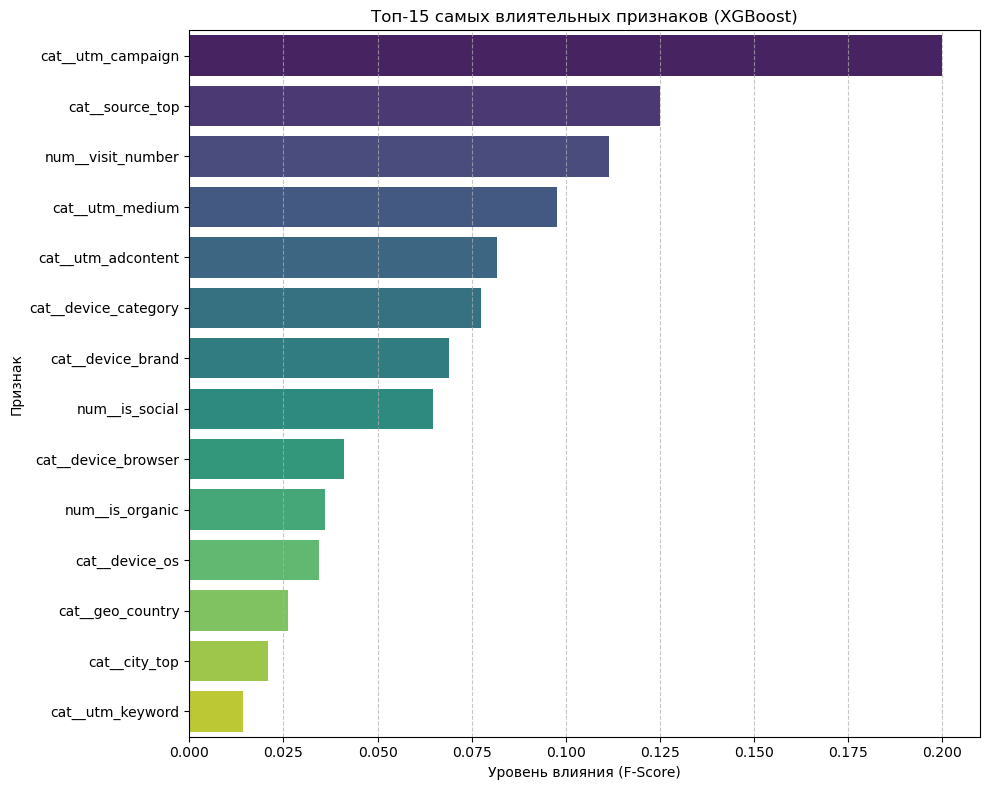


XGBoost Feature Importance Top-10:
             feature  importance
   cat__utm_campaign    0.199978
     cat__source_top    0.124878
   num__visit_number    0.111501
     cat__utm_medium    0.097674
  cat__utm_adcontent    0.081755
cat__device_category    0.077469
   cat__device_brand    0.068976
      num__is_social    0.064658
 cat__device_browser    0.041092
     num__is_organic    0.035970


In [ ]:
# XGBoost Feature Importance
importances_xgb = model_xgb.named_steps['classifier'].feature_importances_

feature_names = model_xgb.named_steps['preprocessor'].get_feature_names_out()

xgb_feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances_xgb
}).sort_values(by='importance', ascending=False)

# Топ-15 фичей XGBoost
plt.figure(figsize=(10, 8))
sns.barplot(data=xgb_feature_importance.head(15), x='importance', y='feature', 
            hue='feature', palette='viridis', legend=False)

plt.title('Топ-15 самых влиятельных признаков (XGBoost)')
plt.xlabel('Уровень влияния (F-Score)')
plt.ylabel('Признак')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nXGBoost Feature Importance Top-10:")
print(xgb_feature_importance.head(10).to_string(index=False))


## Итоговый вывод

В ходе экспериментов построены прогностические модели для предсказания конверсии. Лучший результат показал **Random Forest (ROC-AUC = 0.6778)**, что на 0.30% превосходит XGBoost (0.6748). Ансамблевые модели оказались устойчивы к дисбалансу классов (1:27).

### Ключевые факторы конверсии

| Признак | Random Forest | XGBoost |
|---------|---------------|---------|
| `utm_campaign` | 0.228 | 0.200 |
| `utm_medium` | 0.153 | 0.098 |
| `source_top` | 0.132 | 0.125 |
| `visit_number` | 0.138 | 0.112 |
| `utm_adcontent` | 0.091 | 0.082 |
| `is_organic` | 0.036 | 0.036 |

**Основные выводы:**
- `utm_campaign` — лидирует в обеих моделях (важность ~0.20-0.23)
- Random Forest выше оценил `utm_medium` (0.153 против 0.098 у XGBoost)
- `visit_number` — стабильно важный признак в обеих моделях (~0.11-0.14)
- XGBoost выделяет `device_category` (0.077), которого нет в топ-10 Random Forest
- Технические параметры (`device_brand`, `device_browser`) играют второстепенную роль

## **Сериализация модели:**
- Обученная модель и шаги предобработки (пайплайн) будут сохранены с использованием библиотеки **`joblib`**.

In [79]:
import joblib

# Сериализуем и сохраняем полный пайплайн
joblib.dump(model_rf, 'model_rf.pkl')

['model_rf.pkl']